In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
import numpy as np
import scipy.io
import mne
import os
import sys
import statsmodels.api as sm
from scipy.stats import ttest_1samp, ttest_rel
from scipy import stats
from mne.time_frequency import tfr_morlet
from statsmodels.stats.outliers_influence import variance_inflation_factor


# --- 1. 修改路径为服务器路径 ---
in_path = '/root/seeg_roi_1246/acc/'  
in_path_baseline = '/root/seeg_roi_44/acc/'  
model_data_path = '/root/results/bhm_final_fix_beta_26/weighted/'  # HBM模型输出路径
output_path = '/root/results/glm_tfr_analysis_bga/acc/fix_beta/'  # 输出路径
debug_path = '/root/results/glm_tfr_analysis/debug_logs/'  # 调试日志路径

# 创建输出目录
for path in [output_path, debug_path]:
    if not os.path.exists(path):
        os.makedirs(path)

# 被试列表
subjects = [1, 2, 6, 7, 10, 11, 16, 20, 21, 25]

# 为通道级别GLM结果准备存储结构
all_channels_reward_betas = []
all_channels_info_betas = []
all_channel_names = []
all_channel_subjects = []


# --- 2. 高斯滤波函数 ---
def gaussian_filter(data, time_span=50, fs=1000, axis=-1):
    """
    对数据进行高斯平滑（纯numpy实现）
    """
    from scipy import ndimage

    winsize = int(time_span * fs / 1000)
    x = np.arange(winsize) - winsize // 2
    std = winsize / 5
    window = np.exp(-(x**2) / (2 * std**2))
    gusWin = window / np.sum(window)

    data_filtered = ndimage.convolve1d(
        input=data,
        weights=gusWin,
        axis=axis,
        mode='nearest',
        origin=0
    )
    return data_filtered


# --- 3. 公共baseline zlogratio函数 ---
def apply_common_baseline_zlogratio(tfr_data, times, baseline=(-3.498, -3.002), eps=1e-12):
    """
    使用“所有trial平均后的公共baseline”对所有trial做 zlogratio baseline correction

    zlogratio 逻辑：
        1) 先计算公共baseline均值 mean_baseline
        2) 对所有数据做 log10(data / mean_baseline)
        3) 再除以公共baseline在logratio空间下的标准差

    参数
    ----
    tfr_data : np.ndarray
        shape = (n_trials, n_channels, n_freqs, n_times)
    times : np.ndarray
        shape = (n_times,)
    baseline : tuple
        baseline时间窗，例如 (-3.498, -3.002)
    eps : float
        防止除零和log(0)

    返回
    ----
    corrected_data : np.ndarray
        baseline校正后的数据，shape与输入相同
    baseline_mean : np.ndarray
        公共baseline均值，shape = (n_channels, n_freqs, 1)
    baseline_std : np.ndarray
        公共baseline在logratio空间的标准差，shape = (n_channels, n_freqs, 1)
    """
    baseline_mask = (times >= baseline[0]) & (times <= baseline[1])

    if not np.any(baseline_mask):
        raise ValueError(f"baseline window {baseline} 在times中没有对应采样点")

    # 取出所有trial的baseline段
    # shape: (n_trials, n_channels, n_freqs, n_baseline_times)
    baseline_data_all_trials = tfr_data[:, :, :, baseline_mask]

    # 所有trial先平均
    # shape: (n_channels, n_freqs, n_baseline_times)
    baseline_data_mean_across_trials = np.mean(baseline_data_all_trials, axis=0)

    # 公共baseline均值（在baseline时间维度上再平均）
    # shape: (n_channels, n_freqs, 1)
    baseline_mean = np.mean(baseline_data_mean_across_trials, axis=-1, keepdims=True)
    baseline_mean = np.maximum(baseline_mean, eps)

    # 公共baseline在logratio空间的标准差
    # shape: (n_channels, n_freqs, n_baseline_times)
    baseline_logratio = np.log10(np.maximum(baseline_data_mean_across_trials, eps) / baseline_mean)

    # shape: (n_channels, n_freqs, 1)
    baseline_std = np.std(baseline_logratio, axis=-1, keepdims=True)
    baseline_std = np.maximum(baseline_std, eps)

    # 对所有trial应用公共baseline zlogratio
    corrected_data = np.log10(np.maximum(tfr_data, eps) / baseline_mean[None, :, :, :]) / baseline_std[None, :, :, :]

    return corrected_data, baseline_mean, baseline_std


# --- 4. 时频分析参数 ---
freqs = np.arange(40, 151, 5)   # 实际是 80-140 Hz
n_cycles = freqs / 4.
time_span = 100  # 高斯滤波窗口大小（ms）

whole_range = [-3, 0.999]
baseline_range = [0, 0.498]
time_range = np.arange(baseline_range[0] - baseline_range[1] + whole_range[0], whole_range[1], 0.001)

# 定义决策窗口
decision_window = [-0.8, 0.1]
decision_window_mask = (time_range >= decision_window[0]) & (time_range <= decision_window[1])
decision_times = time_range[decision_window_mask]

print(f"时频参数:")
print(f"  频率范围: {freqs[0]}-{freqs[-1]} Hz (High Gamma), {len(freqs)} points")
print(f"  时间范围: {time_range[0]:.3f}-{time_range[-1]:.3f} s")
print(f"  决策窗口: {decision_window[0]}-{decision_window[1]} s, {len(decision_times)} points")

# 公共baseline窗口
common_baseline_window = (-3.498, -3.002)
print(f"  公共baseline窗口: {common_baseline_window[0]}-{common_baseline_window[1]} s")

# 第二阶段：GLM分析（通道水平）
print("\n=== 第二阶段：通道水平GLM分析 ===")

for subject_idx, subject_id in enumerate(subjects):
    print(f"\n处理被试 {subject_id}...")

    try:
        # --------------------------------------------------
        # 1) 读取主epochs
        # --------------------------------------------------
        ROI_epochs = mne.read_epochs_eeglab(in_path + str(subject_id) + '.set')

        selected_tags = [tag for tag in ROI_epochs.event_id if '99' not in tag]
        pn_epochs = ROI_epochs[selected_tags]

        if len(pn_epochs) == 0:
            print(f"  警告：被试 {subject_id} 没有可用的主epochs，跳过")
            continue

        # 主任务数据TFR
        tfr_ROI_epoch_pn = tfr_morlet(
            pn_epochs,
            freqs=freqs,
            n_cycles=n_cycles,
            return_itc=False,
            average=False,
            use_fft=True
        )

        # --------------------------------------------------
        # 2) 读取baseline epochs
        # --------------------------------------------------
        baseline_epoches = mne.read_epochs_eeglab(in_path_baseline + str(subject_id) + '.set')

        base_selected_tags = [tag for tag in baseline_epoches.event_id.keys() if '99' not in tag]
        pn_epochs_base = baseline_epoches[base_selected_tags]

        if len(pn_epochs_base) != len(pn_epochs):
            print(f"  警告：被试 {subject_id} 的baseline epochs数量({len(pn_epochs_base)})与主epochs数量({len(pn_epochs)})不一致，跳过该被试")
            continue

        # baseline数据TFR
        tfr_ROI_epoch_pn_base = tfr_morlet(
            pn_epochs_base,
            freqs=freqs,
            n_cycles=n_cycles,
            return_itc=False,
            average=False,
            use_fft=True
        )

        # --------------------------------------------------
        # 3) baseline裁剪 + 拼接
        # --------------------------------------------------
        this_baseline_interval = [0.002, 0.498]
        this_baseline_epochs_pn = tfr_ROI_epoch_pn_base.copy().crop(
            tmin=this_baseline_interval[0],
            tmax=this_baseline_interval[1]
        )

        # 拼接 baseline段 + 主任务段
        # shape: (n_trials, n_channels, n_freqs, n_times_total)
        this_pn_mean_tfr = np.concatenate(
            (this_baseline_epochs_pn.data, tfr_ROI_epoch_pn.data),
            axis=3
        )

        info = mne.create_info(
            ch_names=ROI_epochs.ch_names,
            ch_types='eeg',
            sfreq=1000
        )

        this_all_pn_mean_tfr = mne.time_frequency.EpochsTFR(
            info=info,
            data=this_pn_mean_tfr,
            times=time_range,
            freqs=freqs
        )

        # --------------------------------------------------
        # 4) 核心修改：公共baseline zlogratio校正
        # --------------------------------------------------
        try:
            corrected_data, baseline_mean, baseline_std = apply_common_baseline_zlogratio(
                tfr_data=this_all_pn_mean_tfr.data,
                times=time_range,
                baseline=common_baseline_window,
                eps=1e-12
            )
            this_all_pn_mean_tfr.data = corrected_data

            print(f"  公共baseline zlogratio校正完成")
            print(f"    baseline_mean shape = {baseline_mean.shape}")
            print(f"    baseline_std shape  = {baseline_std.shape}")

        except Exception as e:
            print(f"  错误：被试 {subject_id} 的公共baseline zlogratio校正失败: {e}")
            continue

        # --------------------------------------------------
        # 5) 对频率维度取平均 (High Gamma Power)
        # --------------------------------------------------
        this_mean_across_freq = np.mean(this_all_pn_mean_tfr.data, axis=2)

        # --------------------------------------------------
        # 6) 高斯平滑
        # --------------------------------------------------
        this_smooth_hgb_pn_data = np.zeros_like(this_mean_across_freq)

        for ep_idx in range(this_mean_across_freq.shape[0]):
            for ch_idx in range(this_mean_across_freq.shape[1]):
                this_smooth_hgb_pn_data[ep_idx, ch_idx, :] = gaussian_filter(
                    data=this_mean_across_freq[ep_idx, ch_idx, :],
                    time_span=time_span,
                    fs=ROI_epochs.info['sfreq']
                )

        # --------------------------------------------------
        # 7) 加载HBM模型输出
        # --------------------------------------------------
        game_metrics_file = f"{subject_id}_game_metrics.csv"
        game_metrics_path = os.path.join(model_data_path, game_metrics_file)

        if not os.path.exists(game_metrics_path):
            print(f"  错误：找不到被试 {subject_id} 的game_metrics文件")
            continue

        this_game_metrics = pd.read_csv(game_metrics_path)

        # --------------------------------------------------
        # 8) Epoch到Game的映射
        # --------------------------------------------------
        this_epoch_to_game_trial = {}
        game_numbers = this_game_metrics['Game'].values

        for i in range(min(len(pn_epochs.events), len(game_numbers))):
            game = game_numbers[i]
            this_epoch_to_game_trial[i] = (game, 1)

        # --------------------------------------------------
        # 9) 提取行为变量
        # --------------------------------------------------
        this_rel_rewards = []
        this_info_gains = []
        this_valid_epochs = []

        for epoch_idx in range(len(pn_epochs)):
            if epoch_idx not in this_epoch_to_game_trial:
                continue

            game, trial = this_epoch_to_game_trial[epoch_idx]
            game_data = this_game_metrics[this_game_metrics['Game'] == game]

            if len(game_data) == 0:
                continue

            try:
                chosen_deck = int(game_data['Chosen_Deck'].values[0])

                # Q值（相对奖励）
                q_chosen = game_data[f'Q_Deck_{chosen_deck}'].values[0]
                q_unchosen = [
                    game_data[f'Q_Deck_{deck}'].values[0]
                    for deck in range(1, 4) if deck != chosen_deck
                ]
                rel_reward = q_chosen - np.mean(q_unchosen)

                # 相对信息增益
                info_chosen = game_data[f'Weighted_I_transformed_Deck_{chosen_deck}'].values[0]
                info_unchosen = [
                    game_data[f'Weighted_I_transformed_Deck_{deck}'].values[0]
                    for deck in range(1, 4) if deck != chosen_deck
                ]
                # rel_info_gain = -(info_chosen - np.mean(info_unchosen))
                rel_info_gain = -info_chosen

                this_rel_rewards.append(rel_reward)
                this_info_gains.append(rel_info_gain)
                this_valid_epochs.append(epoch_idx)

            except Exception:
                continue

        if not this_valid_epochs:
            print(f"  警告：被试 {subject_id} 没有有效epochs用于GLM，跳过")
            continue

        # --------------------------------------------------
        # 10) 截取有效神经数据
        # --------------------------------------------------
        this_valid_epochs = [idx for idx in this_valid_epochs if idx < this_smooth_hgb_pn_data.shape[0]]

        if len(this_valid_epochs) == 0:
            print(f"  警告：被试 {subject_id} 有效epoch索引超界，跳过")
            continue

        this_valid_data = this_smooth_hgb_pn_data[this_valid_epochs, :, :]

        # 截取有效行为数据
        min_len = len(this_valid_epochs)
        this_rel_rewards = this_rel_rewards[:min_len]
        this_info_gains = this_info_gains[:min_len]

        if min_len < 5:
            print(f"  警告：被试 {subject_id} 有效trial过少({min_len})，跳过")
            continue

        # --------------------------------------------------
        # 11) Z-score 标准化
        # --------------------------------------------------
        this_rel_rewards = np.array(this_rel_rewards)
        this_info_gains = np.array(this_info_gains)

        reward_std = np.std(this_rel_rewards)
        info_std = np.std(this_info_gains)

        if reward_std == 0 or info_std == 0:
            print(f"  警告：被试 {subject_id} 的行为变量标准差为0，跳过")
            continue

        this_rel_rewards_z = (this_rel_rewards - np.mean(this_rel_rewards)) / reward_std
        this_info_gains_z = (this_info_gains - np.mean(this_info_gains)) / info_std

        # --------------------------------------------------
        # 12) 正交化: Info orthogonalized w.r.t Reward
        # --------------------------------------------------
        raw_corr = np.corrcoef(this_rel_rewards_z, this_info_gains_z)[0, 1]

        slope, intercept = np.polyfit(this_rel_rewards_z, this_info_gains_z, 1)
        predicted_info = slope * this_rel_rewards_z + intercept

        # 残差：剔除与Reward相关的Info成分
        this_info_gains_orth = this_info_gains_z - predicted_info

        orth_corr = np.corrcoef(this_rel_rewards_z, this_info_gains_orth)[0, 1]
        print(f"  [共线性处理] 原始 r={raw_corr:.3f} -> 正交化后 r={orth_corr:.3f} (应近似为0)")

        # --------------------------------------------------
        # 13) GLM 拟合（通道 × 时间点）
        # --------------------------------------------------
        for ch_idx in range(this_valid_data.shape[1]):
            ch_name = ROI_epochs.ch_names[ch_idx]
            ch_beta_reward = np.zeros(this_valid_data.shape[2])
            ch_beta_info = np.zeros(this_valid_data.shape[2])

            for t in range(this_valid_data.shape[2]):
                y = this_valid_data[:, ch_idx, t]

                X = np.column_stack([
                    this_rel_rewards_z,
                    this_info_gains_orth,
                    np.ones(len(this_rel_rewards_z))
                ])

                try:
                    model = sm.OLS(y, X)
                    results = model.fit()

                    ch_beta_reward[t] = results.params[0]
                    ch_beta_info[t] = results.params[1]

                except Exception:
                    ch_beta_reward[t] = np.nan
                    ch_beta_info[t] = np.nan

            all_channels_reward_betas.append(ch_beta_reward)
            all_channels_info_betas.append(ch_beta_info)
            all_channel_names.append(f"sub{subject_id}_{ch_name}")
            all_channel_subjects.append(subject_id)

        print(f"  被试 {subject_id} 处理完成")

    except Exception as e:
        print(f"  错误：处理被试 {subject_id} 时发生错误: {e}")
        continue


# ==========================================================
# 后续统计和绘图代码保持不变
# ==========================================================
channel_level_reward = np.array(all_channels_reward_betas)
channel_level_info = np.array(all_channels_info_betas)

print(f"\n通道水平数据形状: {channel_level_reward.shape}")

channel_level_reward_decision = channel_level_reward[:, decision_window_mask]
channel_level_info_decision = channel_level_info[:, decision_window_mask]


=== 第三阶段：通道水平排列检验 ===
对奖励beta值进行排列检验...
Using a threshold of 1.984723
stat_fun(H1): min=-1.189260 max=2.379008
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

对信息beta值进行排列检验...
Using a threshold of 1.984723
stat_fun(H1): min=-2.134963 max=2.543598
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

完成。

=== 第四阶段：可视化结果与统计报告 ===
对奖励和信息beta值的差异进行排列检验...
Using a threshold of 1.984723
stat_fun(H1): min=-1.762251 max=2.030641
Running initial clustering …
Found 1 cluster


  0%|          | Permuting : 0/4999 [00:00<?,       ?it/s]

✓ 统计报告已保存: /root/results/glm_tfr_analysis_bga/acc/fix_beta/statistical_report.txt
⚠ 未发现显著簇，未生成CSV文件

【统计结果摘要】
分析的通道总数: 98
分析的被试数: 10
频段: High Gamma (70-150 Hz)
决策窗口: [-0.6, 0.1] s

Reward Beta 统计:
  均值: 0.0010
  标准差: 0.0147
  峰值时间: -0.369 s

Information Beta 统计 (正交化后):
  均值: 0.0006
  标准差: 0.0289
  峰值时间: -0.246 s



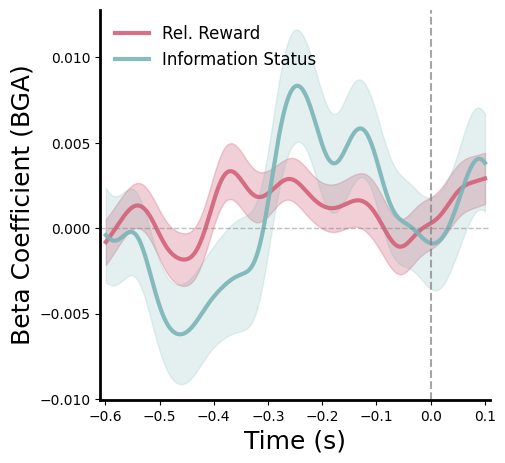

✓ 图形已保存: /root/results/glm_tfr_analysis_bga/acc/fix_beta/channel_level_reward_info_comparison_highgamma.png
✓ 排列测试原始数据已保存: /root/results/glm_tfr_analysis_bga/acc/fix_beta/channel_level_permutation_results.npy
✓ 通道信息已保存: /root/results/glm_tfr_analysis_bga/acc/fix_beta/channel_info.csv

【文件输出列表】
1. 统计报告: statistical_report.txt
2. 簇信息表格: significant_clusters.csv
3. 可视化图形: channel_level_reward_info_comparison_highgamma.png
4. 原始数据: channel_level_permutation_results.npy
5. 通道信息: channel_info.csv

=== 分析完成 ===


In [2]:
import logging
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
# --- 统计检验 ---
print("\n=== 第三阶段：通道水平排列检验 ===")
n_permutations = 5000

print("对奖励beta值进行排列检验...")
T_obs_reward, clusters_reward, cluster_p_values_reward, H0_reward = mne.stats.permutation_cluster_1samp_test(
    channel_level_reward_decision, out_type='mask', n_permutations=n_permutations, n_jobs=6)

print("对信息beta值进行排列检验...")
T_obs_info, clusters_info, cluster_p_values_info, H0_info = mne.stats.permutation_cluster_1samp_test(
    channel_level_info_decision, out_type='mask', n_permutations=n_permutations, n_jobs=6)

print("完成。")
# 屏蔽 matplotlib 的 font 警告
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

print("\n=== 第四阶段：可视化结果与统计报告 ===")

# ============ 计算通道平均值和标准误 ============
# 这些变量在原可视化代码中缺失，需要先计算
channel_mean_reward = np.nanmean(channel_level_reward_decision, axis=0)
channel_sem_reward = np.nanstd(channel_level_reward_decision, axis=0) / np.sqrt(channel_level_reward_decision.shape[0])

channel_mean_info = np.nanmean(channel_level_info_decision, axis=0)
channel_sem_info = np.nanstd(channel_level_info_decision, axis=0) / np.sqrt(channel_level_info_decision.shape[0])

# ============ 计算差异检验 ============
# 对 Reward vs Info 的差异进行排列检验
print("对奖励和信息beta值的差异进行排列检验...")
diff_data = channel_level_reward_decision - channel_level_info_decision
T_obs_diff, clusters_diff, cluster_p_values_diff, H0_diff = mne.stats.permutation_cluster_1samp_test(
    diff_data, out_type='mask', n_permutations=n_permutations, n_jobs=6)

# ============ 计算统计参数 ============
degrees_of_freedom = channel_level_reward_decision.shape[0] - 1  # n-1
t_value_threshold = stats.t.ppf(1 - 0.025, degrees_of_freedom)

# ============ 1. 创建详细统计报告 ============
report_path = os.path.join(output_path, 'statistical_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("GLM-Based Time-Frequency Analysis Report (High Gamma Band)\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")
    
    # 基本信息
    f.write("【1. DATA SUMMARY】\n")
    f.write(f"  Number of subjects: {len(subjects)}\n")
    f.write(f"  Total channels analyzed: {len(all_channel_names)}\n")
    f.write(f"  Channels per subject: {pd.Series(all_channel_subjects).value_counts().to_dict()}\n")
    f.write(f"  Frequency range: {freqs[0]}-{freqs[-1]} Hz (High Gamma band)\n")  # 修改
    f.write(f"  Decision window: {decision_window[0]} to {decision_window[1]} s\n")
    f.write(f"  Time points in decision window: {len(decision_times)}\n")
    f.write(f"  Gaussian smoothing window: {time_span} ms\n\n")
    
    # Beta值统计
    f.write("【2. BETA VALUES STATISTICS】\n")
    f.write(f"  Reward Beta:\n")
    f.write(f"    Mean ± SD: {np.nanmean(channel_level_reward_decision):.4f} ± {np.nanstd(channel_level_reward_decision):.4f}\n")
    f.write(f"    Range: [{np.nanmin(channel_level_reward_decision):.4f}, {np.nanmax(channel_level_reward_decision):.4f}]\n")
    f.write(f"    Peak time: {decision_times[np.nanargmax(np.abs(channel_mean_reward))]:.3f} s\n\n")
    
    f.write(f"  Information Beta (Orthogonalized):\n")  # 修改
    f.write(f"    Mean ± SD: {np.nanmean(channel_level_info_decision):.4f} ± {np.nanstd(channel_level_info_decision):.4f}\n")
    f.write(f"    Range: [{np.nanmin(channel_level_info_decision):.4f}, {np.nanmax(channel_level_info_decision):.4f}]\n")
    f.write(f"    Peak time: {decision_times[np.nanargmax(np.abs(channel_mean_info))]:.3f} s\n\n")
    
    # 排列检验参数
    f.write("【3. PERMUTATION TEST PARAMETERS】\n")
    f.write(f"  Number of permutations: {n_permutations}\n")
    f.write(f"  Statistical threshold (alpha): 0.05\n")
    f.write(f"  Tail: two-tailed\n")
    f.write(f"  Degrees of freedom: {degrees_of_freedom}\n")
    f.write(f"  T-value threshold: {t_value_threshold:.4f}\n\n")
    
    # Reward 簇结果
    f.write("【4. REWARD BETA SIGNIFICANT CLUSTERS】\n")
    if clusters_reward is not None and len(clusters_reward) > 0:
        sig_count = 0
        for i_c, c in enumerate(clusters_reward):
            if cluster_p_values_reward[i_c] <= 0.05:
                sig_count += 1
                # 提取索引
                if isinstance(c, tuple) and len(c) > 0 and isinstance(c[0], slice):
                    c_idx = np.arange(c[0].start, c[0].stop)
                elif hasattr(c, 'start') and hasattr(c, 'stop'):
                    c_idx = np.arange(c.start, c.stop)
                elif isinstance(c, np.ndarray) and c.ndim == 1:
                    c_idx = np.where(c)[0]
                else:
                    continue
                
                if len(c_idx) > 0:
                    start_time = decision_times[c_idx[0]]
                    end_time = decision_times[c_idx[-1]]
                    duration = end_time - start_time
                    peak_idx = c_idx[np.argmax(np.abs(channel_mean_reward[c_idx]))]
                    peak_time = decision_times[peak_idx]
                    peak_value = channel_mean_reward[peak_idx]
                    
                    f.write(f"  Cluster {sig_count}:\n")
                    f.write(f"    Time window: [{start_time:.3f}, {end_time:.3f}] s (duration: {duration:.3f} s)\n")
                    f.write(f"    p-value: {cluster_p_values_reward[i_c]:.4f}\n")
                    f.write(f"    Peak: {peak_value:.4f} at {peak_time:.3f} s\n")
                    f.write(f"    Number of time points: {len(c_idx)}\n\n")
        
        f.write(f"  Total significant clusters: {sig_count}\n\n")
    else:
        f.write("  No significant clusters found.\n\n")
    
    # Information 簇结果
    f.write("【5. INFORMATION BETA SIGNIFICANT CLUSTERS (Orthogonalized)】\n")  # 修改
    if clusters_info is not None and len(clusters_info) > 0:
        sig_count = 0
        for i_c, c in enumerate(clusters_info):
            if cluster_p_values_info[i_c] <= 0.05:
                sig_count += 1
                # 提取索引
                if isinstance(c, tuple) and len(c) > 0 and isinstance(c[0], slice):
                    c_idx = np.arange(c[0].start, c[0].stop)
                elif hasattr(c, 'start') and hasattr(c, 'stop'):
                    c_idx = np.arange(c.start, c.stop)
                elif isinstance(c, np.ndarray) and c.ndim == 1:
                    c_idx = np.where(c)[0]
                else:
                    continue
                
                if len(c_idx) > 0:
                    start_time = decision_times[c_idx[0]]
                    end_time = decision_times[c_idx[-1]]
                    duration = end_time - start_time
                    peak_idx = c_idx[np.argmax(np.abs(channel_mean_info[c_idx]))]
                    peak_time = decision_times[peak_idx]
                    peak_value = channel_mean_info[peak_idx]
                    
                    f.write(f"  Cluster {sig_count}:\n")
                    f.write(f"    Time window: [{start_time:.3f}, {end_time:.3f}] s (duration: {duration:.3f} s)\n")
                    f.write(f"    p-value: {cluster_p_values_info[i_c]:.4f}\n")
                    f.write(f"    Peak: {peak_value:.4f} at {peak_time:.3f} s\n")
                    f.write(f"    Number of time points: {len(c_idx)}\n\n")
        
        f.write(f"  Total significant clusters: {sig_count}\n\n")
    else:
        f.write("  No significant clusters found.\n\n")
    
    # Reward vs Info 差异结果
    f.write("【6. REWARD vs INFORMATION DIFFERENTIAL CLUSTERS】\n")
    if clusters_diff is not None and len(clusters_diff) > 0:
        sig_count = 0
        for i_c, c in enumerate(clusters_diff):
            if cluster_p_values_diff[i_c] <= 0.05:
                sig_count += 1
                # 提取索引
                if isinstance(c, tuple) and len(c) > 0 and isinstance(c[0], slice):
                    c_idx = np.arange(c[0].start, c[0].stop)
                elif hasattr(c, 'start') and hasattr(c, 'stop'):
                    c_idx = np.arange(c.start, c.stop)
                elif isinstance(c, np.ndarray) and c.ndim == 1:
                    c_idx = np.where(c)[0]
                else:
                    continue
                
                if len(c_idx) > 0:
                    start_time = decision_times[c_idx[0]]
                    end_time = decision_times[c_idx[-1]]
                    duration = end_time - start_time
                    
                    # 计算在该时间窗口内哪个更强
                    mean_reward_in_cluster = np.mean(np.abs(channel_mean_reward[c_idx]))
                    mean_info_in_cluster = np.mean(np.abs(channel_mean_info[c_idx]))
                    dominant = "Reward" if mean_reward_in_cluster > mean_info_in_cluster else "Information"
                    
                    f.write(f"  Cluster {sig_count}:\n")
                    f.write(f"    Time window: [{start_time:.3f}, {end_time:.3f}] s (duration: {duration:.3f} s)\n")
                    f.write(f"    p-value: {cluster_p_values_diff[i_c]:.4f}\n")
                    f.write(f"    Dominant signal: {dominant}\n")
                    f.write(f"    Avg |Reward beta|: {mean_reward_in_cluster:.4f}\n")
                    f.write(f"    Avg |Info beta|: {mean_info_in_cluster:.4f}\n\n")
        
        f.write(f"  Total significant differential clusters: {sig_count}\n\n")
    else:
        f.write("  No significant differential clusters found.\n\n")
    
    # 数据质量检查
    f.write("【7. DATA QUALITY CHECK】\n")
    f.write(f"  NaN values in reward beta: {np.sum(np.isnan(channel_level_reward_decision))}/{channel_level_reward_decision.size} ({np.sum(np.isnan(channel_level_reward_decision))/channel_level_reward_decision.size*100:.2f}%)\n")
    f.write(f"  NaN values in info beta: {np.sum(np.isnan(channel_level_info_decision))}/{channel_level_info_decision.size} ({np.sum(np.isnan(channel_level_info_decision))/channel_level_info_decision.size*100:.2f}%)\n\n")
    
    # 添加正交化信息
    f.write("【8. ORTHOGONALIZATION NOTE】\n")
    f.write(f"  Information Gain has been orthogonalized with respect to Relative Reward\n")
    f.write(f"  to remove shared variance and isolate independent effects.\n")
    f.write(f"  This addresses multicollinearity (original correlation r > 0.7).\n\n")
    
    f.write("=" * 80 + "\n")
    f.write("Report End\n")
    f.write("=" * 80 + "\n")

print(f"✓ 统计报告已保存: {report_path}")

# ============ 2. 创建簇信息CSV表格 ============
def extract_cluster_info(clusters, cluster_p_values, beta_values, signal_name):
    """提取簇信息为DataFrame"""
    cluster_list = []
    
    if clusters is not None and len(clusters) > 0:
        for i_c, c in enumerate(clusters):
            if cluster_p_values[i_c] <= 0.05:
                # 提取索引
                if isinstance(c, tuple) and len(c) > 0 and isinstance(c[0], slice):
                    c_idx = np.arange(c[0].start, c[0].stop)
                elif hasattr(c, 'start') and hasattr(c, 'stop'):
                    c_idx = np.arange(c.start, c.stop)
                elif isinstance(c, np.ndarray) and c.ndim == 1:
                    c_idx = np.where(c)[0]
                else:
                    continue
                
                if len(c_idx) > 0:
                    cluster_list.append({
                        'Signal': signal_name,
                        'Cluster_ID': i_c + 1,
                        'Start_Time': decision_times[c_idx[0]],
                        'End_Time': decision_times[c_idx[-1]],
                        'Duration': decision_times[c_idx[-1]] - decision_times[c_idx[0]],
                        'P_Value': cluster_p_values[i_c],
                        'Peak_Value': beta_values[c_idx[np.argmax(np.abs(beta_values[c_idx]))]],
                        'Peak_Time': decision_times[c_idx[np.argmax(np.abs(beta_values[c_idx]))]],
                        'Num_Points': len(c_idx)
                    })
    
    return pd.DataFrame(cluster_list)

# 合并所有簇信息
reward_clusters_df = extract_cluster_info(clusters_reward, cluster_p_values_reward, channel_mean_reward, 'Reward')
info_clusters_df = extract_cluster_info(clusters_info, cluster_p_values_info, channel_mean_info, 'Information_Orthogonalized')  # 修改

all_clusters_df = pd.concat([reward_clusters_df, info_clusters_df], ignore_index=True)
if not all_clusters_df.empty:
    all_clusters_df = all_clusters_df.sort_values('Start_Time').reset_index(drop=True)
    clusters_csv_path = os.path.join(output_path, 'significant_clusters.csv')
    all_clusters_df.to_csv(clusters_csv_path, index=False, float_format='%.4f')
    print(f"✓ 簇信息表格已保存: {clusters_csv_path}")
else:
    print("⚠ 未发现显著簇，未生成CSV文件")

# ============ 3. 改进的控制台输出 ============
print("\n" + "="*60)
print("【统计结果摘要】")
print("="*60)
print(f"分析的通道总数: {len(all_channel_names)}")
print(f"分析的被试数: {len(subjects)}")
print(f"频段: High Gamma (70-150 Hz)")  # 新增
print(f"决策窗口: [{decision_window[0]}, {decision_window[1]}] s")
print(f"\nReward Beta 统计:")
print(f"  均值: {np.nanmean(channel_level_reward_decision):.4f}")
print(f"  标准差: {np.nanstd(channel_level_reward_decision):.4f}")
print(f"  峰值时间: {decision_times[np.nanargmax(np.abs(channel_mean_reward))]:.3f} s")
print(f"\nInformation Beta 统计 (正交化后):")  # 修改
print(f"  均值: {np.nanmean(channel_level_info_decision):.4f}")
print(f"  标准差: {np.nanstd(channel_level_info_decision):.4f}")
print(f"  峰值时间: {decision_times[np.nanargmax(np.abs(channel_mean_info))]:.3f} s")
print("="*60 + "\n")

# ============ 4. 可视化 ============
# 定义样式参数
#line_color = ["#BF0046","#47A4BB"] 86BBBD
line_color = ["#D36179","#7BB5B7"] 
figsize = (6, 6)
title_size = 20
legend_size = 12
ticksize = 30
labelsize = 18
spines_width = 2
subplots_adjust = [0.2, 0.2, 0.85, 0.85]

# 绘制图形
plt.close('all')
plt.figure(figsize=figsize)

# 绘制均值线
plt.plot(decision_times, channel_mean_reward, color=line_color[0], alpha=0.9, linewidth=3, label='Rel. Reward')
plt.plot(decision_times, channel_mean_info, color=line_color[1], alpha=0.9, linewidth=3, label='Information Status')  # 修改

# 添加图例
plt.legend(fontsize=legend_size, frameon=False, loc='upper left')

# 在 t=0 处添加垂直线（决策点）
plt.axvline(0, c="gray", ls="dashed", linewidth=1.5, alpha=0.7)

# 在 y=0 处添加水平线（无效果）
plt.axhline(0, color="gray", linestyle="--", alpha=0.5, linewidth=1)

# 添加标准误阴影区域
plt.fill_between(decision_times, 
                 channel_mean_reward - channel_sem_reward, 
                 channel_mean_reward + channel_sem_reward, 
                 color=line_color[0], alpha=0.3)
plt.fill_between(decision_times, 
                 channel_mean_info - channel_sem_info, 
                 channel_mean_info + channel_sem_info, 
                 color=line_color[1], alpha=0.2)

# 高亮显示奖励的显著簇
if clusters_reward is not None and len(clusters_reward) > 0:
    for i_c, c in enumerate(clusters_reward):
        if cluster_p_values_reward[i_c] <= 0.05:
            # 提取索引
            if isinstance(c, tuple) and len(c) > 0 and isinstance(c[0], slice):
                c_idx = np.arange(c[0].start, c[0].stop)
            elif hasattr(c, 'start') and hasattr(c, 'stop'):
                c_idx = np.arange(c.start, c.stop)
            elif isinstance(c, np.ndarray) and c.ndim == 1:
                c_idx = np.where(c)[0]
            else:
                print(f"警告：奖励簇 {i_c} 的格式无法识别: {type(c)}")
                continue
                
            if len(c_idx) > 0:
                plt.plot(decision_times[c_idx], channel_mean_reward[c_idx], 
                         color=line_color[0], alpha=0.7, linewidth=10)
                print(f"✓ Reward显著簇: [{decision_times[c_idx[0]]:.3f}, {decision_times[c_idx[-1]]:.3f}] s, p={cluster_p_values_reward[i_c]:.4f}")
else:
    print("⚠ 没有找到Reward的显著簇")

# 高亮显示信息的显著簇
if clusters_info is not None and len(clusters_info) > 0:
    for i_c, c in enumerate(clusters_info):
        if cluster_p_values_info[i_c] <= 0.05:
            # 提取索引
            if isinstance(c, tuple) and len(c) > 0 and isinstance(c[0], slice):
                c_idx = np.arange(c[0].start, c[0].stop)
            elif hasattr(c, 'start') and hasattr(c, 'stop'):
                c_idx = np.arange(c.start, c.stop)
            elif isinstance(c, np.ndarray) and c.ndim == 1:
                c_idx = np.where(c)[0]
            else:
                print(f"警告：信息簇 {i_c} 的格式无法识别: {type(c)}")
                continue
                
            if len(c_idx) > 0:
                plt.plot(decision_times[c_idx], channel_mean_info[c_idx], 
                         color=line_color[1], alpha=0.7, linewidth=10)
                print(f"✓ Info显著簇: [{decision_times[c_idx[0]]:.3f}, {decision_times[c_idx[-1]]:.3f}] s, p={cluster_p_values_info[i_c]:.4f}")
else:
    print("⚠ 没有找到Info的显著簇")

# 高亮显示奖励和信息显著不同的时间段
if clusters_diff is not None and len(clusters_diff) > 0:
    for i_c, c in enumerate(clusters_diff):
        if cluster_p_values_diff[i_c] <= 0.05:
            # 提取索引
            if isinstance(c, tuple) and len(c) > 0 and isinstance(c[0], slice):
                c_idx = np.arange(c[0].start, c[0].stop)
            elif hasattr(c, 'start') and hasattr(c, 'stop'):
                c_idx = np.arange(c.start, c.stop)
            elif isinstance(c, np.ndarray) and c.ndim == 1:
                c_idx = np.where(c)[0]
            else:
                print(f"警告：差异簇 {i_c} 的格式无法识别: {type(c)}")
                continue
                
            if len(c_idx) > 0:
                plt.axvspan(decision_times[c_idx[0]], decision_times[c_idx[-1]], color='#A3C4BC', alpha=0.2)
                print(f"✓ 差异显著簇: [{decision_times[c_idx[0]]:.3f}, {decision_times[c_idx[-1]]:.3f}] s, p={cluster_p_values_diff[i_c]:.4f}")
else:
    print("⚠ 没有找到Reward vs Info的显著差异簇")

# 调整图形
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], 
                   right=subplots_adjust[2], top=subplots_adjust[3])

# 设置坐标轴范围
plt.xlim([decision_times[0]-0.01, decision_times[-1]+0.01])
# 根据数据范围设置 y 轴范围
y_min = min(min(channel_mean_reward - channel_sem_reward), min(channel_mean_info - channel_sem_info)) * 1.1
y_max = max(max(channel_mean_reward + channel_sem_reward), max(channel_mean_info + channel_sem_info)) * 1.1
plt.ylim(y_min, y_max)

# 设置样式
ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)

# 配置刻度
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# 设置标签
plt.xlabel("Time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("Beta Coefficient (BGA)", size=labelsize, fontproperties='Arial')  # 修改

# 设置刻度标签
plt.yticks(fontsize=ticksize, fontproperties='Arial')
plt.xticks(fontsize=ticksize, fontproperties='Arial')

# 保存图形
figure_path = os.path.join(output_path, 'channel_level_reward_info_comparison_highgamma.png')  # 修改文件名
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ 图形已保存: {figure_path}")

# 保存排列测试结果
permutation_results = {
    'decision_times': decision_times,
    'channel_mean_reward': channel_mean_reward,
    'channel_sem_reward': channel_sem_reward,
    'channel_mean_info': channel_mean_info,
    'channel_sem_info': channel_sem_info,
    'reward_t_obs': T_obs_reward,
    'reward_clusters': clusters_reward,
    'reward_cluster_p_values': cluster_p_values_reward,
    'info_t_obs': T_obs_info,
    'info_clusters': clusters_info,
    'info_cluster_p_values': cluster_p_values_info,
    'diff_t_obs': T_obs_diff,
    'diff_clusters': clusters_diff,
    'diff_cluster_p_values': cluster_p_values_diff
}

npy_path = os.path.join(output_path, 'channel_level_permutation_results.npy')
np.save(npy_path, permutation_results)
print(f"✓ 排列测试原始数据已保存: {npy_path}")

# 创建所有通道的数据框
channel_data = pd.DataFrame({
    'channel_name': all_channel_names,
    'subject_id': all_channel_subjects
})

# 保存通道信息
channel_info_path = os.path.join(output_path, 'channel_info.csv')
channel_data.to_csv(channel_info_path, index=False)
print(f"✓ 通道信息已保存: {channel_info_path}")

print("\n" + "="*60)
print("【文件输出列表】")
print("="*60)
print(f"1. 统计报告: statistical_report.txt")
print(f"2. 簇信息表格: significant_clusters.csv")
print(f"3. 可视化图形: channel_level_reward_info_comparison_highgamma.png")
print(f"4. 原始数据: channel_level_permutation_results.npy")
print(f"5. 通道信息: channel_info.csv")
print("="*60)

print("\n=== 分析完成 ===")